# 3 — Analysis and geospatial visualisation

**Inputs:**

| File | Contents |
|---|---|
| `data/raw/trips_clean.parquet` | Cleaned citywide trip records. Used for every distribution, outlier, and geospatial result. |
| `data/curated/model_table.parquet` | The airport-hour table. Used for the target, temporal, flight, and weather results. |
| `data/curated/shapes_taxi.json` | Preprocessing shapes, used to verify this notebook reads what 2a wrote. |
| `data/landing/tlc/taxi_zone_lookup.csv`, `data/landing/tlc/taxi_zones/` | Zone names, boroughs, and the zone shapefile [2]. |

**Outputs:** seven figures in `plots/`, plus `data/curated/distribution_summary.csv` and
`data/curated/analysis_findings.json`, which holds the computed values the report quotes.

## Flow

1. Distributions and outliers on the full cleaned data — one-pass summary across four
   segments, Tukey fences, a profile of the extreme trips, the fare spectrum, and the
   null audit.
2. The distribution of the modelling target, and its conditional dispersion.
3. Temporal structure: pickups and mean fare by hour of day and day of week.
4. Flights to pickups: the conversion rate and the lag at which arrivals lead pickups.
5. Weather, compared within `(airport, hour-of-day)` cells, plus a storm case study.
6. Geospatial: where airport trips end, by airport and by time of day.
7. Write `analysis_findings.json`.

Every comparison in Step 5 is made **within** an `(airport, hour-of-day)` cell and then
aggregated across cells, which removes the hour-of-day confound by construction.

## Sampling policy

No result in this notebook is computed on a sample. Every distribution, percentile, outlier
count, and aggregate is computed in Spark over the full cleaned dataset or the full
airport-hour table.

Sampling appears in one place: the scatter plot in Figure 1(b), which cannot render 4.65M
markers legibly. It draws a 1% sample with a fixed seed, both stated in the code and in the
figure caption.


In [1]:
"""Analysis and geospatial visualisation of the airport pickup market.

Reads the cleaned citywide trip records and the joined airport-hour model
table, and produces the distribution, outlier, temporal, flight, weather, and
geospatial results.

Figures are written to `plots/` through `scripts/plot_utils.py`. Computed
values are written to `data/curated/analysis_findings.json`.
"""

import json
import sys
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize, TwoSlopeNorm
from matplotlib.ticker import NullFormatter, ScalarFormatter
from pyspark.sql import functions as F
from scipy import stats

sys.path.append(str(Path("..") / "scripts"))
from plot_utils import (  # noqa: E402
    BASELINE_COLOUR,
    DIVERGING_CMAP,
    MISSING_COLOUR,
    PALETTE,
    SEQUENTIAL_CMAP,
    airport_colour,
    currency_axis,
    heatmap,
    new_figure,
    save_figure,
    set_plot_style,
)
from spark_utils import (  # noqa: E402
    ARRIVAL_AIRPORTS,
    JFK_ZONE,
    LGA_ZONE,
    create_spark_session,
)

# --- Paths -----------------------------------------------------------------
# Notebook is expected to run from `notebooks/`.
PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
CURATED_DIR = PROJECT_ROOT / "data" / "curated"
LANDING_TLC_DIR = PROJECT_ROOT / "data" / "landing" / "tlc"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Study window ----------------------------------------------------------
# Identical to notebooks 2a, 2b, and 2c.
WINDOW_START = "2023-01-01"
WINDOW_END = "2024-07-01"
WINDOW_DAYS = 547
WINDOW_HOURS = WINDOW_DAYS * 24                          # 13,128 per site
EXPECTED_ROWS = WINDOW_HOURS * len(ARRIVAL_AIRPORTS)     # 26,256

# --- Codes from the data dictionary ----------------------------------------
AIRPORT_ZONES = {JFK_ZONE: "JFK", LGA_ZONE: "LGA"}
UNKNOWN_ZONES = [264, 265]        # "Unknown" and "Outside of NYC / N.A."
PAYMENT_CARD = 1
RATECODE_JFK_FLAT = 2
RATECODE_NAMES = {
    1: "Standard rate",
    2: "JFK flat fare",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride",
    99: "Unknown",
}

# Published JFK–Manhattan flat fare, in force across the study window. No
# result depends on it: Step 1d derives the modal airport fare from the data
# and reports it against this constant so a disagreement is visible.
JFK_FLAT_FARE = 70.00

# --- Sampling policy -------------------------------------------------------
# Used only for the scatter plot in Figure 1(b), and quoted in its caption.
# Every other result here is computed on the full distribution.
SAMPLE_FRACTION = 0.01
SAMPLE_SEED = 42

# --- Night, for the geospatial split ---------------------------------------
# 22:00 to 05:59 inclusive, matching the low-demand block identified in Step 2.
NIGHT_START_HOUR = 22
NIGHT_END_HOUR = 6

set_plot_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
spark = create_spark_session(app_name="MAST30034 — analysis")
spark.sparkContext.setLogLevel("WARN")
spark.version

your 131072x1 screen size is bogus. expect trouble
26/08/17 17:11:51 WARN Utils: Your hostname, iphone resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/08/17 17:11:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/17 17:11:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


'3.5.1'

## Step 1 — Distributions and outliers, on the full data

The cleaned citywide table is read as written by 2a, and both row counts are asserted
against `shapes_taxi.json` so that a partial write or a changed study window fails here
rather than surfacing later as a plausible percentile.

Note on cost: this notebook makes roughly eight passes over the cleaned table. Every one is
column-pruned and none collects more than a few hundred rows to the driver.


In [3]:
trips = (
    spark.read.parquet(str(RAW_DIR / "trips_clean.parquet"))
    .withColumn("is_airport", F.col("pulocationid").isin(list(AIRPORT_ZONES)))
)

with open(CURATED_DIR / "shapes_taxi.json") as handle:
    shapes_taxi = json.load(handle)

clean_total = trips.count()
airport_total = trips.where(F.col("is_airport")).count()

assert clean_total == shapes_taxi["cleaned_citywide_trips"], (
    f"{clean_total:,} rows on disk, 2a wrote "
    f"{shapes_taxi['cleaned_citywide_trips']:,}"
)
assert airport_total == shapes_taxi["airport_pickups"], (
    f"{airport_total:,} airport pickups, 2a wrote "
    f"{shapes_taxi['airport_pickups']:,}"
)

print(f"Cleaned citywide trips  {clean_total:,}")
print(f"Airport pickups         {airport_total:,} "
      f"({100 * airport_total / clean_total:.2f}% of cleaned trips)")

Cleaned citywide trips  56,637,949
Airport pickups         4,653,181 (8.22% of cleaned trips)


### Step 1a — One pass, four segments

Four segments are described: citywide, the two airports together, and each airport alone.
Rather than filtering the frame four times, each segment is a **mask** —
`F.when(predicate, value)` — and all four are aggregated in a single pass, since `F.count`
of a masked column counts only its non-null values.

`tip_ratio` carries a second restriction inside the mask, because the tip field is populated
for card payments only [1]. This is the same denominator rule 2a applied.

`percentile_approx` trades memory for rank error, and its relative error of `1/accuracy` is
an error in rank. At the default accuracy the rank error would be the whole distance from
p99.9 to the top of the distribution, so `PERCENTILE_ACCURACY` is set to 20,000 and the
exact `F.max` is carried alongside as a check.


In [4]:
PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
PERCENTILE_LABELS = ["p1", "p5", "p25", "p50", "p75", "p95", "p99", "p99_9"]

# Rank error of the sketch, at one part in twenty thousand — finer than the
# most extreme percentile reported.
PERCENTILE_ACCURACY = 20_000

# Segments, as masks rather than as filtered frames.
SEGMENTS = {
    "citywide": F.lit(True),
    "airport": F.col("is_airport"),
    "JFK": F.col("pulocationid") == JFK_ZONE,
    "LGA": F.col("pulocationid") == LGA_ZONE,
}

# Metrics. Duration is converted to minutes so that one unit is used
# throughout.
METRICS = {
    "fare_amount": F.col("fare_amount"),
    "total_amount": F.col("total_amount"),
    "trip_distance_mi": F.col("trip_distance"),
    "duration_min": F.col("trip_duration_s") / 60.0,
    "tip_ratio": F.when(
        F.col("payment_type") == PAYMENT_CARD,
        F.col("tip_amount") / F.col("fare_amount"),
    ),
}


def distribution_expressions(segment: str, predicate, metric: str, value) -> list:
    """Aggregate expressions describing one metric within one segment.

    Args:
        segment: Segment name, used to prefix the output column names.
        predicate: Boolean Column selecting the segment's rows.
        metric: Metric name, used in the output column names.
        value: Column holding the metric. May itself be conditional, in which
            case the two conditions compose.

    Returns:
        List of aggregate Columns, named ``segment|metric|statistic``.
    """
    masked = F.when(predicate, value)
    prefix = f"{segment}|{metric}"
    return [
        F.count(masked).alias(f"{prefix}|n"),
        F.avg(masked).alias(f"{prefix}|mean"),
        F.stddev(masked).alias(f"{prefix}|sd"),
        F.skewness(masked).alias(f"{prefix}|skew"),
        # Exact, unlike the sketch below, and the check on it.
        F.max(masked).alias(f"{prefix}|max"),
        F.percentile_approx(masked, PERCENTILES, PERCENTILE_ACCURACY)
        .alias(f"{prefix}|pct"),
    ]

In [5]:
expressions = [
    expression
    for segment, predicate in SEGMENTS.items()
    for metric, value in METRICS.items()
    for expression in distribution_expressions(segment, predicate, metric, value)
]

# One pass over all 56,637,949 cleaned trips. No sampling.
summary_row = trips.agg(*expressions).collect()[0].asDict()

records = []
for segment in SEGMENTS:
    for metric in METRICS:
        prefix = f"{segment}|{metric}"
        record = {
            "segment": segment,
            "metric": metric,
            "n": summary_row[f"{prefix}|n"],
            "mean": summary_row[f"{prefix}|mean"],
            "sd": summary_row[f"{prefix}|sd"],
            "skew": summary_row[f"{prefix}|skew"],
            "max": summary_row[f"{prefix}|max"],
        }
        record.update(dict(zip(PERCENTILE_LABELS, summary_row[f"{prefix}|pct"])))
        records.append(record)

distributions = pd.DataFrame(records)

# The largest observation's contribution to the variance, as a share of the
# total. Where that share is large the moments describe a single record, and
# the rank statistics should be quoted instead.
distributions["max_share_of_variance"] = (
    (distributions["max"] - distributions["mean"]) ** 2
    / (distributions["n"] * distributions["sd"] ** 2)
)

distributions.to_csv(CURATED_DIR / "distribution_summary.csv", index=False)
print(f"Written to {CURATED_DIR / 'distribution_summary.csv'}")

# The sketch check: p99.9 must not equal the maximum. If it does, raise
# PERCENTILE_ACCURACY.
degenerate = distributions[
    np.isclose(distributions["p99_9"], distributions["max"])
]
if len(degenerate):
    print("\nWARNING: p99.9 equals the maximum for "
          f"{len(degenerate)} segment-metric pairs — the sketch is "
          "under-resolved at that percentile. Raise PERCENTILE_ACCURACY.")

dominated = distributions[distributions["max_share_of_variance"] > 0.10]
if len(dominated):
    print("\nOne record accounts for more than 10% of the variance here — "
          "quote the quartiles, not the standard deviation or the skewness:")
    for row in dominated.itertuples():
        print(f"  {row.segment:<9} {row.metric:<17} max = {row.max:>12,.2f}  "
              f"{100 * row.max_share_of_variance:5.1f}% of variance")

distributions.round(3)

26/08/17 17:12:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Written to /home/tavish/projects/project-1-individual-SavvyHack/data/curated/distribution_summary.csv

One record accounts for more than 10% of the variance here — quote the quartiles, not the standard deviation or the skewness:
  citywide  fare_amount       max =   386,983.63   67.1% of variance
  citywide  total_amount      max =   386,987.63   64.1% of variance
  citywide  tip_ratio         max =    27,500.00   22.1% of variance
  airport   tip_ratio         max =    21,000.00   36.2% of variance
  JFK       tip_ratio         max =    21,000.00   43.8% of variance
  LGA       tip_ratio         max =    14,500.00   99.5% of variance


,segment,metric,n,mean,sd,skew,max,p1,p5,p25,p50,p75,p95,p99,p99_9,max_share_of_variance
0,citywide,fare_amount,56637949,19.603,62.754,4820.351,386983.630,4.400,5.800,9.300,13.500,21.900,66.000,74.000,140.200,0.671
1,citywide,total_amount,56637949,28.625,64.215,4498.509,386987.630,9.400,11.750,15.960,21.000,30.600,82.300,103.360,172.900,0.641
2,citywide,trip_distance_mi,56637949,3.476,4.500,3.175,334.090,0.310,0.550,1.090,1.800,3.440,15.080,20.170,29.510,0.000
3,citywide,duration_min,56637949,16.477,13.335,2.654,360.000,2.233,3.800,7.800,12.750,20.633,42.733,67.033,99.333,0.000
4,citywide,tip_ratio,44485655,0.255,8.769,2060.228,27500.000,0.000,0.017,0.200,0.259,0.306,0.402,0.527,1.111,0.221
5,airport,fare_amount,4653181,55.684,24.389,3.877,1916.800,12.100,21.900,40.100,55.500,70.000,79.300,135.300,272.200,0.001
6,airport,total_amount,4653181,76.078,28.821,2.772,1939.550,18.850,30.050,60.700,77.040,92.690,105.190,165.070,315.400,0.001
7,airport,trip_distance_mi,4653181,13.552,6.094,1.590,281.760,2.100,4.600,9.150,12.370,18.000,21.600,29.180,51.400,0.000
8,airport,duration_min,4653181,37.783,18.618,1.345,360.000,6.383,12.617,24.417,35.483,48.350,70.800,90.300,128.600,0.000
9,airport,tip_ratio,3627513,0.233,18.318,992.613,21000.000,0.000,0.000,0.171,0.231,0.268,0.332,0.411,1.007,0.362


### Step 1b — Outliers: Tukey fences on the full distribution

An outlier here is a record that is **extreme**, not one that is invalid: everything invalid
was removed in 2a against a documented business rule, and everything merely extreme was
retained so that this step can describe it.

Tukey's fence, `p75 + 1.5 × IQR`, is used because it is a function of the quartiles rather
than of the mean and standard deviation, and every metric here is heavily right-skewed.

Only the upper fence is counted: each metric is already bounded below by a 2a filter, so
nothing can lie below the lower fence.


In [6]:
TUKEY_MULTIPLIER = 1.5

fences = distributions.assign(
    iqr=lambda frame: frame["p75"] - frame["p25"],
)
fences["upper_fence"] = fences["p75"] + TUKEY_MULTIPLIER * fences["iqr"]

# Count what lies beyond each fence, again in one pass over the full data.
exceedance_expressions = [
    F.sum(
        F.when(
            SEGMENTS[row.segment] & (METRICS[row.metric] > row.upper_fence), 1
        ).otherwise(0)
    ).alias(f"{row.segment}|{row.metric}")
    for row in fences.itertuples()
]
exceedance_row = trips.agg(*exceedance_expressions).collect()[0].asDict()

fences["n_above_fence"] = [
    exceedance_row[f"{row.segment}|{row.metric}"] for row in fences.itertuples()
]
fences["pct_above_fence"] = 100 * fences["n_above_fence"] / fences["n"]

fences[[
    "segment", "metric", "p25", "p50", "p75", "upper_fence", "p99_9", "max",
    "n_above_fence", "pct_above_fence",
]].round(3)

,segment,metric,p25,p50,p75,upper_fence,p99_9,max,n_above_fence,pct_above_fence
0,citywide,fare_amount,9.300,13.500,21.900,40.800,140.200,386983.630,5612865,9.910
1,citywide,total_amount,15.960,21.000,30.600,52.560,172.900,386987.630,6328970,11.174
2,citywide,trip_distance_mi,1.090,1.800,3.440,6.965,29.510,334.090,7420446,13.102
3,citywide,duration_min,7.800,12.750,20.633,39.883,99.333,360.000,3393023,5.991
4,citywide,tip_ratio,0.200,0.259,0.306,0.463,1.111,27500.000,932263,2.096
5,airport,fare_amount,40.100,55.500,70.000,114.850,272.200,1916.800,66018,1.419
6,airport,total_amount,60.700,77.040,92.690,140.675,315.400,1939.550,67029,1.440
7,airport,trip_distance_mi,9.150,12.370,18.000,31.275,51.400,281.760,34889,0.750
8,airport,duration_min,24.417,35.483,48.350,84.250,128.600,360.000,76449,1.643
9,airport,tip_ratio,0.171,0.231,0.268,0.414,1.007,21000.000,34934,0.963


### Step 1c — What the extreme trips are

Airport trips beyond the fare fence are profiled by **rate code** and **drop-off borough**.
Rate code is the informative dimension because it is entered at the meter and describes the
fare regime: code 4 is the Nassau or Westchester out-of-city rate, code 5 is a negotiated
fare, and code 3 is Newark [1].


In [7]:
# `keep_default_na=False`: zone 265's borough is the literal string "N/A"
# (outside the five boroughs), which pandas would otherwise read as missing.
zone_lookup = pd.read_csv(
    LANDING_TLC_DIR / "taxi_zone_lookup.csv", keep_default_na=False
).rename(
    columns={
        "LocationID": "locationid",
        "Borough": "borough",
        "Zone": "zone",
        "service_zone": "service_zone",
    }
)

# Renamed so the two sentinel zones read as categories.
zone_lookup["borough"] = zone_lookup["borough"].replace(
    {"N/A": "Outside NYC", "Unknown": "Unknown zone"}
)

# 265 rows joined to a multi-million-row frame, so broadcast rather than
# shuffled.
dropoff_zones = (
    spark.createDataFrame(zone_lookup[["locationid", "borough", "zone"]])
    .withColumnRenamed("locationid", "dolocationid")
    .withColumnRenamed("borough", "dropoff_borough")
    .withColumnRenamed("zone", "dropoff_zone")
)

airport_fare_fence = float(
    fences.loc[
        (fences["segment"] == "airport") & (fences["metric"] == "fare_amount"),
        "upper_fence",
    ].iloc[0]
)

extremes = (
    trips
    .where(F.col("is_airport") & (F.col("fare_amount") > airport_fare_fence))
    .join(F.broadcast(dropoff_zones), "dolocationid", "left")
    .groupBy("ratecodeid", "dropoff_borough")
    .agg(
        F.count("*").alias("trips"),
        F.avg("fare_amount").alias("mean_fare"),
        F.avg("trip_distance").alias("mean_distance_mi"),
        F.avg(F.col("trip_duration_s") / 60.0).alias("mean_duration_min"),
    )
    .toPandas()
)

# `ratecodeid` is nullable and arrives as a float, so it is cast before the
# int-keyed lookup.
extremes["rate_code"] = (
    extremes["ratecodeid"]
    .map(lambda value: RATECODE_NAMES.get(int(value)) if pd.notna(value) else None)
    .fillna("Unrecorded")
)
extremes["pct_of_extremes"] = 100 * extremes["trips"] / extremes["trips"].sum()

extreme_total = int(extremes["trips"].sum())
extreme_pct = 100 * extreme_total / airport_total
print(f"Airport trips above the ${airport_fare_fence:,.2f} fare fence: "
      f"{extreme_total:,} ({extreme_pct:.2f}% of airport pickups)")

extremes.nlargest(10, "trips")[[
    "rate_code", "dropoff_borough", "trips", "pct_of_extremes",
    "mean_fare", "mean_distance_mi", "mean_duration_min",
]].round(2).reset_index(drop=True)

Airport trips above the $114.85 fare fence: 66,018 (1.42% of airport pickups)


,rate_code,dropoff_borough,trips,pct_of_extremes,mean_fare,mean_distance_mi,mean_duration_min
0,Nassau or Westchester,Outside NYC,33634,50.95,179.46,32.51,57.31
1,Negotiated fare,Outside NYC,14698,22.26,182.57,34.75,68.31
2,Newark,EWR,4963,7.52,151.85,34.95,68.38
3,Standard rate,Outside NYC,2963,4.49,154.43,40.38,75.57
4,Newark,Outside NYC,2736,4.14,157.67,36.03,73.24
5,Standard rate,Staten Island,919,1.39,128.64,33.62,70.53
6,Standard rate,Brooklyn,913,1.38,124.61,28.43,88.14
7,Standard rate,Manhattan,749,1.13,129.89,28.24,98.94
8,Nassau or Westchester,EWR,638,0.97,176.40,35.17,67.18
9,Standard rate,Bronx,613,0.93,124.83,30.03,82.34


### Step 1d — The fare spectrum and the flat-fare mass point

Every distinct metered fare value is counted in one pass, per segment. The modal JFK fare is
then derived from the data and reported against the published flat fare held in
`JFK_FLAT_FARE`, so that a disagreement between the two is visible rather than silent.

Both denominators are printed, since the natural claim is JFK-relative and mixing a JFK
numerator with an airport denominator invites a misreading.


In [8]:
fare_spectrum = (
    trips
    .select(
        F.round("fare_amount", 2).alias("fare"),
        F.col("is_airport"),
        F.col("pulocationid"),
    )
    .groupBy("fare")
    .agg(
        F.count("*").alias("trips"),
        F.sum(F.col("is_airport").cast("int")).alias("airport_trips"),
        F.sum(F.when(F.col("pulocationid") == JFK_ZONE, 1).otherwise(0))
        .alias("jfk_trips"),
    )
    .toPandas()
    .sort_values("fare")
    .reset_index(drop=True)
)
print(f"{len(fare_spectrum):,} distinct metered fare values across "
      f"{clean_total:,} trips")

modal = fare_spectrum.nlargest(6, "jfk_trips").copy()
modal["pct_of_jfk"] = 100 * modal["jfk_trips"] / shapes_taxi["airport_pickups"]
print("\nMost common fare values among JFK pickups:")
print(modal[["fare", "jfk_trips", "airport_trips", "trips"]].to_string(index=False))

# The derived modal fare, reported against the published constant.
modal_fare = float(modal["fare"].iloc[0])
flat_mask = np.isclose(fare_spectrum["fare"], JFK_FLAT_FARE)
trips_at_flat = int(fare_spectrum.loc[flat_mask, "jfk_trips"].sum())

agreement = (
    "agree" if np.isclose(modal_fare, JFK_FLAT_FARE)
    else "DISAGREE — check the TLC fare schedule"
)
# Both denominators, since the natural claim is the JFK-relative one.
jfk_pickups = int(fare_spectrum["jfk_trips"].sum())
flat_pct_jfk = 100 * trips_at_flat / jfk_pickups
flat_pct_airport = 100 * trips_at_flat / shapes_taxi["airport_pickups"]

print(f"\nModal JFK fare      ${modal_fare:,.2f}")
print(f"Published flat fare ${JFK_FLAT_FARE:,.2f}  — {agreement}")
print(f"JFK pickups billing exactly ${JFK_FLAT_FARE:,.2f}: {trips_at_flat:,}")
print(f"  {flat_pct_jfk:.1f}% of JFK pickups, "
      f"{flat_pct_airport:.1f}% of all airport pickups")
print(f"Rate Code 2 trips recorded by 2a: "
      f"{shapes_taxi['ratecode_2_trips']:,}")
print("  The 2a count covers both directions of the flat fare, so it exceeds "
      "the JFK pickups above by the Manhattan-to-JFK trips, which are not "
      "part of the airport pickup set.")

12,872 distinct metered fare values across 56,637,949 trips

Most common fare values among JFK pickups:
 fare  jfk_trips  airport_trips   trips
 70.0    1492107        1495201 2030465
 44.3      27530          76875  139011
 45.0      23056          71513  133232
 43.6      18340          68288  134273
 60.4      15555          26402   36794
 59.7      15207          26987   38010

Modal JFK fare      $70.00
Published flat fare $70.00  — agree
JFK pickups billing exactly $70.00: 1,492,107
  54.2% of JFK pickups, 32.1% of all airport pickups
Rate Code 2 trips recorded by 2a: 2,019,422
  The 2a count covers both directions of the flat fare, so it exceeds the JFK pickups above by the Manhattan-to-JFK trips, which are not part of the airport pickup set.


Saved plots/fig01_fare_distribution.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig01_fare_distribution.png')

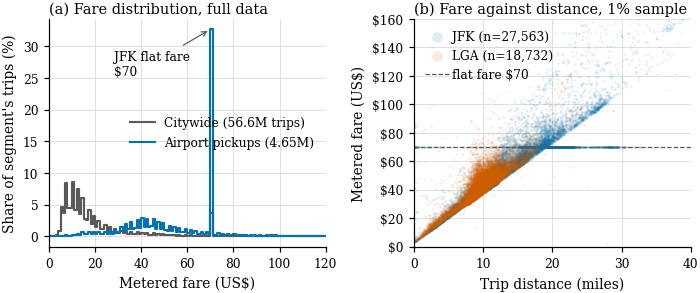

In [9]:
# --- Figure 1 --------------------------------------------------------------
# (a) fare distribution, airport against citywide, from the full value
#     spectrum; (b) fare against distance, the only sampled result here.
BIN_WIDTH = 1.0
FARE_PLOT_MAX = 120.0
DISTANCE_PLOT_MAX = 40.0
FARE_SCATTER_MAX = 160.0

binned = (
    fare_spectrum[fare_spectrum["fare"] <= FARE_PLOT_MAX]
    .assign(bin=lambda frame: np.floor(frame["fare"] / BIN_WIDTH) * BIN_WIDTH)
    .groupby("bin")[["trips", "airport_trips"]]
    .sum()
)
# Denominators are the full segment totals rather than the plotted range, so
# the truncated tail shows as a shortfall rather than being renormalised away.
citywide_share = 100 * binned["trips"] / clean_total
airport_share = 100 * binned["airport_trips"] / airport_total

scatter = (
    trips
    .where(F.col("is_airport"))
    # The metered fare, not the total: the flat fare is the metered
    # component, so the reference line only lines up with `fare_amount`.
    .select("trip_distance", "fare_amount", "pulocationid")
    .sample(fraction=SAMPLE_FRACTION, seed=SAMPLE_SEED)
    .toPandas()
)
scatter["airport"] = np.where(scatter["pulocationid"] == JFK_ZONE, "JFK", "LGA")

fig, axes = new_figure(1, 2, height=2.9)

ax = axes[0]
ax.step(binned.index, citywide_share, where="post", color=BASELINE_COLOUR,
        label=f"Citywide ({clean_total / 1e6:.1f}M trips)")
ax.step(binned.index, airport_share, where="post", color=PALETTE["blue"],
        label=f"Airport pickups ({airport_total / 1e6:.2f}M)")
flat_bin = float(np.floor(JFK_FLAT_FARE / BIN_WIDTH) * BIN_WIDTH)
peak = float(airport_share.get(flat_bin, 0.0))
ax.annotate(
    f"JFK flat fare\n${JFK_FLAT_FARE:,.0f}",
    xy=(flat_bin, peak),
    xytext=(flat_bin - 42, peak * 0.78),
    arrowprops={"arrowstyle": "->", "lw": 0.8, "color": PALETTE["grey"]},
    fontsize=8,
)
ax.set_xlim(0, FARE_PLOT_MAX)
ax.set_xlabel("Metered fare (US$)")
ax.set_ylabel("Share of segment's trips (%)")
ax.set_title("(a) Fare distribution, full data")
# Centre right: the spike occupies the upper right and the annotation the
# upper left.
ax.legend(loc="center right")

ax = axes[1]
for airport, group in scatter.groupby("airport"):
    ax.scatter(group["trip_distance"], group["fare_amount"], s=2, alpha=0.12,
               linewidths=0, color=airport_colour(airport),
               label=f"{airport} (n={len(group):,})")
ax.axhline(JFK_FLAT_FARE, color=PALETTE["grey"], lw=0.8, ls="--",
           label=f"flat fare ${JFK_FLAT_FARE:,.0f}")
ax.set_xlim(0, DISTANCE_PLOT_MAX)
ax.set_ylim(0, FARE_SCATTER_MAX)
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Metered fare (US$)")
ax.set_title(f"(b) Fare against distance, {SAMPLE_FRACTION:.0%} sample")
ax.legend(loc="upper left", markerscale=5, handletextpad=0.2)
currency_axis(ax)

fig.tight_layout()
save_figure(fig, "fig01_fare_distribution")

### Step 1e — Nulls, and what was imputed

The null counts are re-derived from the written model table and each is required to match a
family documented by 2c. The audit mirrors 2c's deliberately, so that an unexplained null
introduced upstream fails here rather than being plotted.

The weather figures printed at the end are the only imputation performed anywhere in the
pipeline: no trip-level value was filled in.


In [10]:
model_table = spark.read.parquet(str(CURATED_DIR / "model_table.parquet"))
assert model_table.count() == EXPECTED_ROWS

null_counts = {
    column: count
    for column, count in model_table.select([
        F.sum(F.col(column).isNull().cast("int")).alias(column)
        for column in model_table.columns
    ]).collect()[0].asDict().items()
    if count
}

# Families, in the order they are tested, mirroring notebook 2c's audit.
LAG_SUFFIXES = ("_lag_1h", "_lag_24h", "_lag_168h", "_same_hour_7d")
EMPTY_HOUR_MEANS = [
    "mean_fare", "median_fare", "mean_total", "mean_distance_mi",
    "mean_duration_min", "mean_passengers", "share_flat_fare",
    "share_flex_fare", "mean_tip_ratio",
]
WEATHER_COLUMNS = [
    "temp_c", "rhum_pct", "prcp_mm", "wspd_kmh", "pres_hpa",
    "is_precip", "is_freezing",
]
NOTHING_SCHEDULED = ["share_longhaul", "share_cancelled", "ewr_share_cancelled"]
DELAY_COLUMNS = [
    "mean_arr_delay_min", "share_delayed_15", "ewr_mean_arr_delay_min",
]
WINDOW_EDGE = ["sched_arrivals_prev_hr", "sched_arrivals_next_hr"]


def null_family(column: str) -> str:
    """Return the documented reason a column contains nulls.

    Args:
        column: Column name from the model table.

    Returns:
        The family label, or ``"UNEXPLAINED"`` if none matches, which the
        assertion below treats as a failure.
    """
    if column.endswith(LAG_SUFFIXES):
        return "no history yet (first week, or first hour of the window)"
    if column in EMPTY_HOUR_MEANS:
        return "statistic of an hour with no pickups"
    if column in WEATHER_COLUMNS:
        return "weather gap beyond the fill limit"
    if column in NOTHING_SCHEDULED:
        return "nothing scheduled to land in the hour"
    if column in DELAY_COLUMNS:
        return "no arrival delay observed in the hour"
    if column in WINDOW_EDGE:
        return "first or last hour of the window"
    if column == "holiday_name":
        return "ordinary (non-holiday) day"
    return "UNEXPLAINED"


null_summary = pd.DataFrame([
    {
        "column": column,
        "nulls": count,
        "pct_of_rows": round(100 * count / EXPECTED_ROWS, 2),
        "family": null_family(column),
    }
    for column, count in sorted(null_counts.items(), key=lambda item: -item[1])
])
assert not (null_summary["family"] == "UNEXPLAINED").any(), (
    "Undocumented nulls: "
    f"{null_summary.loc[null_summary['family'] == 'UNEXPLAINED', 'column'].tolist()}"
)

with open(CURATED_DIR / "shapes_model_table.json") as handle:
    shapes_model = json.load(handle)

print("Null families in the airport-hour table")
print(
    null_summary.groupby("family")
    .agg(columns=("column", "size"), worst_case_rows=("nulls", "max"))
    .sort_values("worst_case_rows", ascending=False)
    .to_string()
)
print("\nThe only imputation performed anywhere in the pipeline:")
print(f"  weather hours carried forward         "
      f"{shapes_model['weather_hours_carried_forward']:,}")
print(f"  weather hours still unobserved        "
      f"{shapes_model['weather_hours_unobserved']:,}")
prcp_filled = shapes_model["precipitation_hours_not_observed_at_site"]
print(f"  precipitation from a neighbour or dry {prcp_filled:,} "
      f"({100 * prcp_filled / EXPECTED_ROWS:.1f}% of airport-hours)")

Null families in the airport-hour table
                                                          columns  worst_case_rows
family                                                                            
ordinary (non-holiday) day                                      1            25104
no history yet (first week, or first hour of the window)       20             5355
no arrival delay observed in the hour                           3             5353
nothing scheduled to land in the hour                           3             5342
statistic of an hour with no pickups                            9             1540
first or last hour of the window                                2                2

The only imputation performed anywhere in the pipeline:
  weather hours carried forward         4
  weather hours still unobserved        0
  precipitation from a neighbour or dry 1,527 (5.8% of airport-hours)


## Step 2 — The distribution of the modelling target

Model 1 predicts `n_pickups`, a count, which points at a Poisson GLM. A Poisson assumes the
conditional variance equals the conditional mean, and that assumption is testable before
anything is fitted.

The test has to be conditional, since the unconditional variance of `n_pickups` mostly
measures the difference between 03:00 and 18:00. The dispersion ratio is therefore computed
within `(airport, hour-of-day)` cells across the 547 days of the window, which is close to
what the model sees once hour is in the linear predictor.

The empty hours are counted alongside, separating the genuine zero-demand hours from the
daylight-saving artefacts 2a flagged.


In [11]:
hours = model_table.toPandas()
hours["date"] = pd.to_datetime(hours["date"])
assert len(hours) == EXPECTED_ROWS

# Conditional dispersion: variance against mean within (airport, hour) cells,
# each holding one observation per day of the window.
cells = (
    hours.groupby(["airport", "hour"])["n_pickups"]
    .agg(mean="mean", variance="var", days="size")
    .reset_index()
)
cells["dispersion"] = cells["variance"] / cells["mean"].where(cells["mean"] > 0)

dispersion_summary = (
    cells.groupby("airport")["dispersion"]
    .agg(median_dispersion="median", min_dispersion="min", max_dispersion="max")
)
overdispersed_cells = int((cells["dispersion"] > 1).sum())

print("Conditional dispersion (variance / mean) within airport-hour cells")
print(dispersion_summary.round(2).to_string())
print(f"\n{overdispersed_cells} of {len(cells)} cells have a ratio above 1")

# Zero-demand hours, and when they happen.
zero_hours = hours[hours["n_pickups"] == 0]
overnight = zero_hours[zero_hours["hour"].between(2, 5)]
print(f"\nAirport-hours with no pickups: {len(zero_hours):,} of {EXPECTED_ROWS:,} "
      f"({100 * len(zero_hours) / EXPECTED_ROWS:.1f}%)")
print(f"  of which 02:00–05:59: {len(overnight):,} "
      f"({100 * len(overnight) / len(zero_hours):.1f}% of them)")
# Five of the six daylight-saving rows read as empty, because the 02:00 that
# does not exist was zero-filled by the spine.
genuine_zero = zero_hours[~zero_hours["dst_anomaly"].astype(bool)]
artefacts = len(zero_hours) - len(genuine_zero)
print(f"  of which genuine: {len(genuine_zero):,} "
      f"({artefacts} are daylight-saving artefacts, not observed demand)")
print(zero_hours.groupby("airport").size().to_string())

Conditional dispersion (variance / mean) within airport-hour cells
         median_dispersion  min_dispersion  max_dispersion
airport                                                   
JFK                  12.44            7.56           43.02
LGA                  21.40            1.70           53.86

48 of 48 cells have a ratio above 1

Airport-hours with no pickups: 1,180 of 26,256 (4.5%)
  of which 02:00–05:59: 1,017 (86.2% of them)
  of which genuine: 1,175 (5 are daylight-saving artefacts, not observed demand)
airport
JFK      47
LGA    1133


Saved plots/fig02_target_distribution.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig02_target_distribution.png')

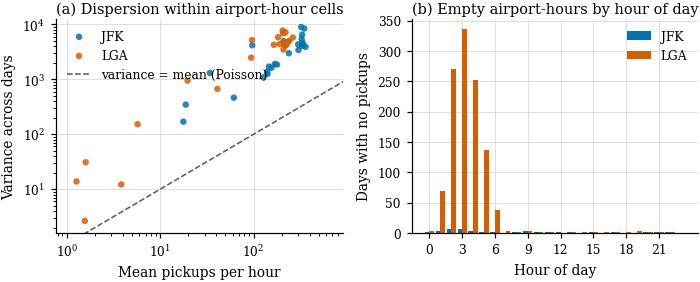

In [12]:
# --- Figure 2 --------------------------------------------------------------
# (a) variance against mean per cell, with the equality line the Poisson
#     assumption implies; (b) empty hours by hour of day.
fig, axes = new_figure(1, 2, height=2.8)

ax = axes[0]
for airport, group in cells.groupby("airport"):
    ax.scatter(group["mean"], group["variance"], s=18, alpha=0.85,
               color=airport_colour(airport), label=airport, edgecolors="none")
# The equality line spans the range the data occupies rather than a hardcoded
# lower bound.
limit = max(cells["mean"].max(), cells["variance"].max()) * 1.4
lower = float(cells.loc[cells["mean"] > 0, "mean"].min())
reference = np.array([lower, limit])
ax.plot(reference, reference, color=PALETTE["grey"], lw=1.0, ls="--",
        label="variance = mean (Poisson)")
ax.set_xscale("log")
ax.set_yscale("log")
# Bounded to the data: the equality line runs to the largest variance, which
# is far beyond the largest mean.
ax.set_xlim(lower * 0.6, float(cells["mean"].max()) * 2.5)
ax.set_ylim(float(cells["variance"].min()) * 0.6, limit)
ax.set_xlabel("Mean pickups per hour")
ax.set_ylabel("Variance across days")
ax.set_title("(a) Dispersion within airport-hour cells")
ax.legend(loc="upper left")

ax = axes[1]
zero_by_hour = (
    zero_hours.groupby(["hour", "airport"]).size().unstack("airport", fill_value=0)
    .reindex(range(24), fill_value=0)
)
width = 0.42
for offset, airport in zip((-width / 2, width / 2), ARRIVAL_AIRPORTS):
    ax.bar(zero_by_hour.index + offset, zero_by_hour.get(airport, 0), width=width,
           color=airport_colour(airport), label=airport)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Days with no pickups")
ax.set_title("(b) Empty airport-hours by hour of day")
ax.legend()

fig.tight_layout()
save_figure(fig, "fig02_target_distribution")

## Step 3 — Temporal structure: volume and value by hour and weekday

Four panels: mean pickups per hour and mean fare per trip, by hour of day and day of week,
for each airport.

The two rows are scaled differently on purpose. Volume shares one scale across both
airports, since they are comparable in trips per hour. Value is scaled **within** each
airport, because the two fare distributions barely overlap and a shared scale would render
both panels as flat blocks of colour. The colour bars carry the ranges, and the report
caption states that the value panels are not on a common scale.

Below the figure the relationship is quantified: a Spearman rank correlation across the 168
cells per airport, and the cells where the two ranks disagree most. The rank-gap table is
restricted to cells averaging at least `MIN_CELL_PICKUPS` pickups, since a mean fare
computed over one or two overnight trips out-ranks anything on noise alone.


Saved plots/fig03_hour_weekday_heatmaps.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig03_hour_weekday_heatmaps.png')

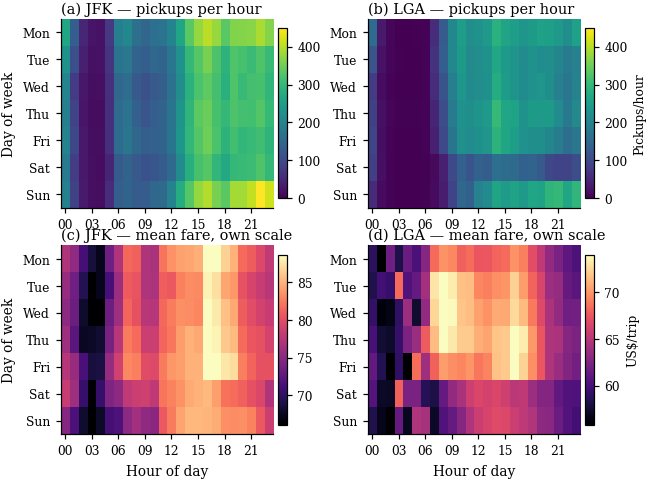

In [13]:
DAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
HOUR_LABELS = [f"{hour:02d}" for hour in range(24)]


def hour_weekday_matrix(frame: pd.DataFrame, value: str) -> np.ndarray:
    """Average a column into a 7 × 24 day-of-week by hour-of-day grid.

    Args:
        frame: Airport-hour rows for a single airport.
        value: Column to average. Nulls are skipped, so an hour with no pickups
            contributes nothing to ``mean_total`` rather than counting as zero.

    Returns:
        A 7 × 24 array, Monday first, reindexed so that a missing combination
        appears as NaN rather than shifting the grid.
    """
    grid = frame.pivot_table(
        index="day_of_week", columns="hour", values=value, aggfunc="mean"
    )
    return grid.reindex(index=range(1, 8), columns=range(24)).to_numpy()


volume_grids = {
    code: hour_weekday_matrix(group, "n_pickups")
    for code, group in hours.groupby("airport")
}
value_grids = {
    code: hour_weekday_matrix(group, "mean_total")
    for code, group in hours.groupby("airport")
}

fig, axes = new_figure(2, 2, height=4.9)

# Volume: one scale across both airports, so the levels are comparable.
volume_max = max(np.nanmax(grid) for grid in volume_grids.values())
for column, airport in enumerate(ARRIVAL_AIRPORTS):
    image = heatmap(
        axes[0][column], volume_grids[airport], DAY_LABELS, HOUR_LABELS,
        vmin=0, vmax=volume_max,
        title=f"({'ab'[column]}) {airport} — pickups per hour",
        ylabel="" if column else "Day of week",
    )
    bar = fig.colorbar(image, ax=axes[0][column], shrink=0.9, pad=0.02)
    # Labelled once per row, on the right, to avoid colliding with the
    # neighbouring panel's ticks.
    bar.set_label("Pickups/hour" if column else "", size=8)

# Value: scaled within airport, and clipped to the 2nd–98th percentile so one
# unusual cell cannot consume the range.
for column, airport in enumerate(ARRIVAL_AIRPORTS):
    grid = value_grids[airport]
    low, high = np.nanpercentile(grid, [2, 98])
    image = heatmap(
        axes[1][column], grid, DAY_LABELS, HOUR_LABELS,
        vmin=low, vmax=high, cmap="magma",
        title=f"({'cd'[column]}) {airport} — mean fare, own scale",
        xlabel="Hour of day", ylabel="" if column else "Day of week",
    )
    bar = fig.colorbar(image, ax=axes[1][column], shrink=0.9, pad=0.02)
    bar.set_label("US$/trip" if column else "", size=8)

save_figure(fig, "fig03_hour_weekday_heatmaps")

In [14]:
def grid_to_long(grid: np.ndarray, airport: str, name: str) -> pd.DataFrame:
    """Reshape a 7 × 24 grid into long form.

    Args:
        grid: Array as returned by :func:`hour_weekday_matrix`.
        airport: Airport code to attach.
        name: Name for the value column.

    Returns:
        A frame with ``day_of_week``, ``hour``, ``airport``, and the value.
    """
    frame = pd.DataFrame(grid, index=range(1, 8), columns=range(24))
    long = frame.stack().reset_index()
    long.columns = ["day_of_week", "hour", name]
    long["airport"] = airport
    return long


cells_long = pd.concat([
    grid_to_long(volume_grids[airport], airport, "mean_pickups").merge(
        grid_to_long(value_grids[airport], airport, "mean_total"),
        on=["day_of_week", "hour", "airport"],
    )
    for airport in ARRIVAL_AIRPORTS
], ignore_index=True)

# Ranked within airport, since the two differ in level.
cells_long["volume_rank"] = cells_long.groupby("airport")["mean_pickups"].rank(pct=True)
cells_long["value_rank"] = cells_long.groupby("airport")["mean_total"].rank(pct=True)
cells_long["rank_gap"] = cells_long["value_rank"] - cells_long["volume_rank"]

print("Rank correlation between volume and value across the 168 cells")
for airport, group in cells_long.groupby("airport"):
    usable = group.dropna(subset=["mean_pickups", "mean_total"])
    rho, pvalue = stats.spearmanr(usable["mean_pickups"], usable["mean_total"])
    print(f"  {airport}  Spearman rho = {rho:+.3f}   p = {pvalue:.2g}   "
          f"n = {len(usable)} cells")

# Cells with almost no trips have a mean fare computed over a handful of
# them, so they are excluded from the ranking below.
MIN_CELL_PICKUPS = 20
substantive = cells_long[cells_long["mean_pickups"] >= MIN_CELL_PICKUPS]
print(f"\n{len(cells_long) - len(substantive)} of {len(cells_long)} cells "
      f"average fewer than {MIN_CELL_PICKUPS} pickups and are excluded from "
      "the ranking below")

print("\nHigh value, low volume — the cells the two models disagree about most")
best_gap = substantive.nlargest(6, "rank_gap").copy()
best_gap["day"] = best_gap["day_of_week"].map(dict(enumerate(DAY_LABELS, start=1)))
print(best_gap[[
    "airport", "day", "hour", "mean_pickups", "mean_total",
    "volume_rank", "value_rank",
]].round(2).to_string(index=False))

Rank correlation between volume and value across the 168 cells
  JFK  Spearman rho = +0.771   p = 2e-34   n = 168 cells
  LGA  Spearman rho = +0.536   p = 7.3e-14   n = 168 cells

51 of 336 cells average fewer than 20 pickups and are excluded from the ranking below

High value, low volume — the cells the two models disagree about most
airport day  hour  mean_pickups  mean_total  volume_rank  value_rank
    LGA Tue     7         65.03       73.07         0.31        0.95
    LGA Wed     7         56.81       72.51         0.30        0.93
    LGA Thu     8        107.10       74.45         0.38        0.99
    LGA Wed     8        117.10       75.18         0.39        1.00
    LGA Tue     8        134.18       74.57         0.42        0.99
    LGA Thu     7         46.78       71.48         0.29        0.86


In [15]:
# Holidays. 2c already flags the three regimes in the table.
hours["day_type"] = np.select(
    [hours["is_holiday"].astype(bool), hours["is_holiday_adjacent"].astype(bool)],
    ["federal holiday", "adjacent travel day"],
    default="ordinary day",
)

holiday_summary = hours.groupby("day_type").agg(
    days=("date", "nunique"),
    mean_pickups_per_hour=("n_pickups", "mean"),
    mean_fare=("mean_total", "mean"),
)
print(holiday_summary.round(2).to_string())

# The adjacent-day flag covers days that behave very differently, so it is
# decomposed by named day rather than reported as one average.
named_days = (
    hours[hours["holiday_name"].notna()]
    .groupby(["holiday_name", "day_type"])["n_pickups"]
    .mean()
    .sort_values()
)
print("\nMean pickups per airport-hour, by named day (quietest first)")
print(named_days.round(1).to_string())

                     days  mean_pickups_per_hour  mean_fare
day_type                                                   
adjacent travel day     6                 155.90      70.04
federal holiday        18                 183.02      70.48
ordinary day          523                 177.27      72.83

Mean pickups per airport-hour, by named day (quietest first)
holiday_name                day_type           
Christmas Eve               adjacent travel day     83.8
Thanksgiving Day            federal holiday         87.9
Christmas Day               federal holiday         99.6
Day after Thanksgiving      adjacent travel day    131.9
Veterans Day                federal holiday        140.7
New Year's Eve              adjacent travel day    151.1
Thanksgiving eve            adjacent travel day    153.4
Day after Christmas         adjacent travel day    163.7
New Year's Day              federal holiday        164.1
Independence Day            federal holiday        168.4
Martin Luther King J

## Step 4 — From flights to pickups

Two quantities.

**Pickups per scheduled arrival**, by airport. BTS covers domestic flights only, so this
ratio measures how much of each airport's traffic the flight feed can see rather than a
behavioural constant.

**The lag at which arrivals predict pickups.** The correlation between pickups and scheduled
arrivals is computed at lags of −2 to +2 hours, by shifting within airport over the
completed hourly grid. The lag with the peak correlation is the empirical basis for carrying
`sched_arrivals_prev_hr` in the feature set.

Panel (b) reports coverage by hour of day as a ratio of sums rather than a mean of ratios,
excluding the hours of the day that average fewer than one scheduled domestic arrival.


In [16]:
conversion = hours.groupby("airport").agg(
    pickups=("n_pickups", "sum"),
    sched_arrivals=("sched_arrivals", "sum"),
    mean_share_longhaul=("share_longhaul", "mean"),
)
conversion["pickups_per_arrival"] = (
    conversion["pickups"] / conversion["sched_arrivals"]
)
print("Domestic scheduled arrivals against observed pickups")
print(conversion.round(3).to_string())

ratio = (
    conversion.loc["JFK", "pickups_per_arrival"]
    / conversion.loc["LGA", "pickups_per_arrival"]
)
print(f"\nJFK converts {ratio:.1f}x as many pickups per *domestic* arrival as LGA.")
print("This is a coverage gap, not a demand effect: BTS does not report the "
      "international arrivals that JFK serves and LaGuardia essentially does not.")

Domestic scheduled arrivals against observed pickups
         pickups  sched_arrivals  mean_share_longhaul  pickups_per_arrival
airport                                                                   
JFK      2753043          193143                0.385               14.254
LGA      1900138          243611                0.034                7.800

JFK converts 1.8x as many pickups per *domestic* arrival as LGA.
This is a coverage gap, not a demand effect: BTS does not report the international arrivals that JFK serves and LaGuardia essentially does not.


In [17]:
LAGS = [-2, -1, 0, 1, 2]

ordered = hours.sort_values(["airport", "date", "hour"]).copy()
lag_rows = []
for airport, group in ordered.groupby("airport"):
    for lag in LAGS:
        shifted = group["sched_arrivals"].shift(lag)
        lag_rows.append({
            "airport": airport,
            "lag_hours": lag,
            "correlation": group["n_pickups"].corr(shifted),
        })
lag_table = pd.DataFrame(lag_rows).pivot(
    index="lag_hours", columns="airport", values="correlation"
)
print("Correlation of pickups with scheduled arrivals, by lag")
print("(positive lag = arrivals that landed that many hours earlier)")
print(lag_table.round(3).to_string())

best_lag = {
    airport: int(lag_table[airport].idxmax()) for airport in lag_table.columns
}
print(f"\nPeak correlation at lag: {best_lag}")

# Pickups per scheduled arrival by hour of day, as a ratio of sums rather than
# a mean of ratios.
per_hour = (
    hours.groupby(["airport", "hour"])[["n_pickups", "sched_arrivals"]]
    .sum()
    .reset_index()
)
per_hour["pickups_per_arrival"] = (
    per_hour["n_pickups"] / per_hour["sched_arrivals"].where(
        per_hour["sched_arrivals"] > 0
    )
)

# Hours of the day averaging fewer than one scheduled arrival a day give a
# ratio that measures its own denominator, so they are excluded.
MIN_SCHED_ARRIVALS = WINDOW_DAYS
thin = per_hour["sched_arrivals"] < MIN_SCHED_ARRIVALS
per_hour.loc[thin, "pickups_per_arrival"] = np.nan
print(f"\n{int(thin.sum())} airport-hours-of-day average fewer than one "
      "scheduled domestic arrival a day and are left out of the coverage "
      "ratio")

Correlation of pickups with scheduled arrivals, by lag
(positive lag = arrivals that landed that many hours earlier)
airport      JFK    LGA
lag_hours              
-2         0.218  0.482
-1         0.483  0.633
 0         0.660  0.801
 1         0.717  0.842
 2         0.646  0.805

Peak correlation at lag: {'JFK': 1, 'LGA': 1}

10 airport-hours-of-day average fewer than one scheduled domestic arrival a day and are left out of the coverage ratio


Saved plots/fig04_flights_to_pickups.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig04_flights_to_pickups.png')

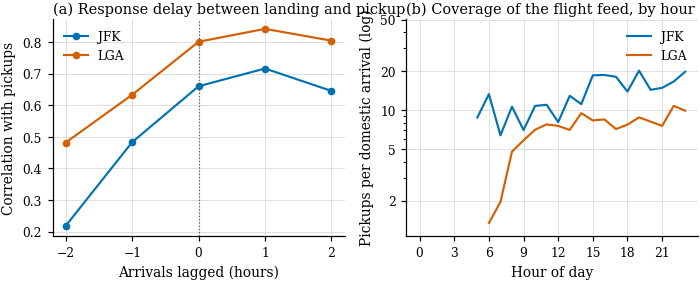

In [18]:
# --- Figure 4 --------------------------------------------------------------
fig, axes = new_figure(1, 2, height=2.8)

ax = axes[0]
for airport in ARRIVAL_AIRPORTS:
    ax.plot(lag_table.index, lag_table[airport], marker="o",
            color=airport_colour(airport), label=airport)
ax.axvline(0, color=PALETTE["grey"], lw=0.8, ls=":")
ax.set_xticks(LAGS)
ax.set_xlabel("Arrivals lagged (hours)")
ax.set_ylabel("Correlation with pickups")
ax.set_title("(a) Response delay between landing and pickup")
ax.legend()

ax = axes[1]
for airport in ARRIVAL_AIRPORTS:
    subset = per_hour[per_hour["airport"] == airport]
    ax.plot(subset["hour"], subset["pickups_per_arrival"],
            color=airport_colour(airport), label=airport)
ax.set_xticks(range(0, 24, 3))
# Log, since the two airports differ by more than the within-day spread of
# either. Plain numbers on the majors, no minor labels.
ax.set_yscale("log")
ratios = per_hour["pickups_per_arrival"].dropna()
ax.set_yticks([1, 2, 5, 10, 20, 50, 100, 200])
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
# After the ticks, not before: setting ticks outside the current view
# expands it again.
ax.set_ylim(float(ratios.min()) * 0.8, float(ratios.max()) * 1.3)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Pickups per domestic arrival (log)")
ax.set_title("(b) Coverage of the flight feed, by hour")
ax.legend()

fig.tight_layout()
save_figure(fig, "fig04_flights_to_pickups")

## Step 5 — Weather, matched on hour of day

Rain is not distributed evenly across the clock and demand varies enormously across the
clock, so every comparison here is made **within** an `(airport, hour-of-day)` cell and then
aggregated across cells.

The aggregation across cells is weighted by the number of wet hours in each cell, and the
percentage change is computed from the weighted aggregates rather than as a weighted mean of
per-cell ratios: a near-empty overnight cell would otherwise contribute a
several-hundred-percent change and dominate the result.

Freezing precipitation is reported with its own count, since the study window coincides with
a record snow drought and the effect is weakly identified.

The storm case study is measured against two independent baselines — the trailing seven-day
mean, and the same weekday within four weeks either side. The trailing-mean baseline is
itself validated against the series it averages before either is quoted, since the same
feature is a model input in notebook 4.


In [19]:
observed = hours[~hours["weather_missing"].astype(bool)].copy()
observed["is_precip"] = observed["is_precip"].fillna(False).astype(bool)
observed["is_freezing"] = observed["is_freezing"].fillna(False).astype(bool)
print(f"{len(observed):,} of {EXPECTED_ROWS:,} airport-hours have observed weather")

cell_stats = (
    observed.groupby(["airport", "hour", "is_precip"])
    .agg(
        mean_pickups=("n_pickups", "mean"),
        mean_fare=("mean_total", "mean"),
        cell_hours=("n_pickups", "size"),
    )
    .reset_index()
)

wet = cell_stats[cell_stats["is_precip"]].set_index(["airport", "hour"])
dry = cell_stats[~cell_stats["is_precip"]].set_index(["airport", "hour"])
matched = wet.join(dry, lsuffix="_wet", rsuffix="_dry", how="inner")
matched["delta_pickups"] = matched["mean_pickups_wet"] - matched["mean_pickups_dry"]
matched["pct_change_pickups"] = (
    100 * matched["delta_pickups"] / matched["mean_pickups_dry"]
)
matched["delta_fare"] = matched["mean_fare_wet"] - matched["mean_fare_dry"]

print("\nWet minus dry, matched within (airport, hour-of-day) cells")
for airport, group in matched.groupby(level="airport"):
    weighted_pickups = np.average(
        group["delta_pickups"], weights=group["cell_hours_wet"]
    )
    weighted_fare = np.average(group["delta_fare"], weights=group["cell_hours_wet"])
    # From the weighted aggregates, not a weighted mean of per-cell ratios.
    weighted_dry = np.average(
        group["mean_pickups_dry"], weights=group["cell_hours_wet"]
    )
    weighted_pct = 100 * weighted_pickups / weighted_dry
    test = stats.ttest_1samp(group["delta_pickups"], 0.0)
    print(f"  {airport}  wet hours = {int(group['cell_hours_wet'].sum()):,}")
    print(f"        pickups  {weighted_pickups:+.1f} per hour "
          f"({weighted_pct:+.1f}%), paired t = {test.statistic:+.2f}, "
          f"p = {test.pvalue:.3f}")
    print(f"        fare     ${weighted_fare:+.2f} per trip")

# Freezing precipitation, reported with its own count.
freezing = observed[observed["is_freezing"]]
print(f"\nFreezing precipitation: {len(freezing):,} airport-hours "
      f"({100 * len(freezing) / len(observed):.2f}% of observed hours)")
if len(freezing):
    # Matched on the hour, exactly as the rain comparison is: freezing hours
    # cluster overnight and in winter.
    freezing_cells = (
        freezing.groupby(["airport", "hour"])["n_pickups"]
        .agg(mean_freezing="mean", freezing_hours="size")
    )
    baseline = (
        observed[~observed["is_freezing"]]
        .groupby(["airport", "hour"])["n_pickups"].mean()
        .rename("mean_otherwise")
    )
    freezing_matched = freezing_cells.join(baseline)
    weights = freezing_matched["freezing_hours"]
    freezing_delta = np.average(
        freezing_matched["mean_freezing"] - freezing_matched["mean_otherwise"],
        weights=weights,
    )
    freezing_base = np.average(freezing_matched["mean_otherwise"], weights=weights)
    print(f"  unmatched: {freezing['n_pickups'].mean():.1f} against "
          f"{observed['n_pickups'].mean():.1f} pickups per hour overall — "
          "mostly the clock, not the ice")
    print(f"  matched within the hour: {freezing_delta:+.1f} pickups "
          f"({100 * freezing_delta / freezing_base:+.1f}%), across "
          f"{len(freezing_matched)} (airport, hour) cells")
else:
    freezing_delta = float("nan")

26,256 of 26,256 airport-hours have observed weather

Wet minus dry, matched within (airport, hour-of-day) cells
  JFK  wet hours = 1,354
        pickups  -4.1 per hour (-2.0%), paired t = -0.99, p = 0.334
        fare     $+0.02 per trip
  LGA  wet hours = 1,402
        pickups  -10.1 per hour (-7.0%), paired t = -2.39, p = 0.025
        fare     $+0.36 per trip

Freezing precipitation: 84 airport-hours (0.32% of observed hours)
  unmatched: 122.8 against 177.2 pickups per hour overall — mostly the clock, not the ice
  matched within the hour: -16.2 pickups (-11.7%), across 41 (airport, hour) cells


Trailing-mean baseline against the series it averages (ratio ≈ 1)
         n_pickups  pickups_same_hour_7d  ratio
airport                                        
JFK        209.446               209.448  1.000
LGA        145.088               144.948  0.999

Wettest day in the window: 2023-09-29 (6.6 mm/hour averaged across the day)
  pickups that day              9,717
  seven-day trailing norm       5,520   (+76.0%)
  same weekday, ±4 weeks        8,419   (+15.4%)   n = 8 days
Quote the smaller of the two effects in the report, and say which baseline it is measured against.
Saved plots/fig05_weather.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig05_weather.png')

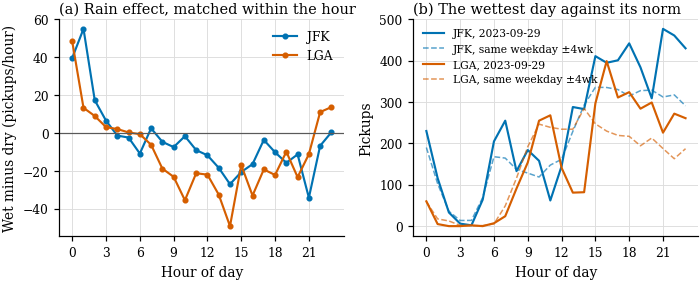

In [20]:
# Baseline check before the case study: a trailing mean must have the same
# long-run average as the series it averages. The same feature is a model input
# in notebook 4, so a failure here matters beyond this cell.
norm_check = (
    hours[hours["has_full_lags"].astype(bool)]
    .groupby("airport")[["n_pickups", "pickups_same_hour_7d"]]
    .mean()
)
norm_check["ratio"] = norm_check["pickups_same_hour_7d"] / norm_check["n_pickups"]
print("Trailing-mean baseline against the series it averages (ratio ≈ 1)")
print(norm_check.round(3).to_string())
baseline_sound = bool(norm_check["ratio"].between(0.95, 1.05).all())
if not baseline_sound:
    print("\nWARNING: `pickups_same_hour_7d` does not track `n_pickups` over "
          "the window. Do not quote the comparison below until the window in "
          "notebook 2c has been checked.")

daily_rain = hours.groupby("date")["prcp_mm"].mean()
storm_date = daily_rain.idxmax()
storm = hours[hours["date"] == storm_date].sort_values(["airport", "hour"])

storm_pickups = int(storm["n_pickups"].sum())
storm_normal = float(storm["pickups_same_hour_7d"].sum())

# A second, independent baseline: the same weekday within four weeks either
# side, excluding the storm itself.
SEASONAL_WINDOW_DAYS = 28
nearby = hours[
    (hours["date"] >= storm_date - pd.Timedelta(days=SEASONAL_WINDOW_DAYS))
    & (hours["date"] <= storm_date + pd.Timedelta(days=SEASONAL_WINDOW_DAYS))
    & (hours["day_of_week"] == int(storm["day_of_week"].iloc[0]))
    & (hours["date"] != storm_date)
]
seasonal_norm = nearby["n_pickups"].sum() / nearby["date"].nunique()

# The same baseline hour by hour, so the plotted counterfactual matches the
# reported percentage.
seasonal_profile = nearby.groupby(["airport", "hour"])["n_pickups"].mean()

print(f"\nWettest day in the window: {storm_date.date()} "
      f"({daily_rain.max():.1f} mm/hour averaged across the day)")
print(f"  pickups that day              {storm_pickups:,}")
print(f"  seven-day trailing norm       {storm_normal:,.0f}   "
      f"({100 * (storm_pickups / storm_normal - 1):+.1f}%)")
print(f"  same weekday, ±4 weeks        {seasonal_norm:,.0f}   "
      f"({100 * (storm_pickups / seasonal_norm - 1):+.1f}%)   "
      f"n = {nearby['date'].nunique()} days")
print("Quote the smaller of the two effects in the report, and say which "
      "baseline it is measured against.")

# --- Figure 5 --------------------------------------------------------------
fig, axes = new_figure(1, 2, height=2.8)

ax = axes[0]
for airport in ARRIVAL_AIRPORTS:
    group = matched.xs(airport, level="airport")
    ax.plot(group.index, group["delta_pickups"], marker="o", markersize=3,
            color=airport_colour(airport), label=airport)
ax.axhline(0, color=PALETTE["grey"], lw=0.8)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Wet minus dry (pickups/hour)")
ax.set_title("(a) Rain effect, matched within the hour")
ax.legend()

ax = axes[1]
for airport in ARRIVAL_AIRPORTS:
    group = storm[storm["airport"] == airport]
    ax.plot(group["hour"], group["n_pickups"], color=airport_colour(airport),
            label=f"{airport}, {storm_date.date()}")
    # The same-weekday baseline rather than the trailing seven-day mean, so
    # the figure and the quoted number agree.
    ax.plot(group["hour"], seasonal_profile.loc[airport].reindex(group["hour"]),
            ls="--", lw=1.0, color=airport_colour(airport), alpha=0.65,
            label=f"{airport}, same weekday ±4wk")
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Pickups")
ax.set_title("(b) The wettest day against its norm")
ax.legend(fontsize=7)

fig.tight_layout()
save_figure(fig, "fig05_weather")

## Step 6 — Geospatial: drop-off geography

Pickups occur in exactly two zones, so the informative map is of **drop-offs from airport
pickups**. Four panels: the drop-off distribution for each airport separately, the mean fare
by drop-off zone, and the day-to-night shift in the destination mix.

Three implementation points:

- **Aggregate in Spark, plot in pandas.** The grouping runs over the airport trips and
  returns at most 263 zones × 2 airports × 2 periods.
- **The CRS.** The TLC shapefile is published in EPSG:2263, the New York State Plane in
  feet [2]. It is converted to EPSG:4326 before use, and the CRS is printed before and after.
- **Zones 264 and 265** have no geometry in the shapefile, so they cannot be mapped. Their
  share of drop-offs is computed and reported in the caption instead.


In [21]:
airport_trips = (
    trips
    .where(F.col("is_airport"))
    .withColumn(
        "airport",
        F.when(F.col("pulocationid") == JFK_ZONE, F.lit("JFK")).otherwise(F.lit("LGA")),
    )
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn(
        "is_night",
        (F.col("pickup_hour") >= NIGHT_START_HOUR)
        | (F.col("pickup_hour") < NIGHT_END_HOUR),
    )
)

# At most 263 zones × 2 airports × 2 periods. Sums are carried rather than
# means so that a later regrouping stays exact.
dropoffs = (
    airport_trips
    .groupBy("airport", "dolocationid", "is_night")
    .agg(
        F.count("*").alias("trips"),
        F.sum("total_amount").alias("sum_total"),
        F.sum("trip_distance").alias("sum_distance_mi"),
        F.sum(F.col("trip_duration_s") / 60.0).alias("sum_duration_min"),
    )
    .toPandas()
)
dropoffs["is_night"] = dropoffs["is_night"].astype(bool)
assert int(dropoffs["trips"].sum()) == airport_total, (
    "The drop-off aggregation lost or duplicated trips"
)

# Citywide originating volume per zone, over the full cleaned dataset — the
# re-hail proxy used in Step 6a.
zone_supply = (
    trips
    .groupBy("pulocationid")
    .agg(F.count("*").alias("citywide_pickups"))
    .toPandas()
    .rename(columns={"pulocationid": "dolocationid"})
)
zone_supply["pickups_per_hour"] = zone_supply["citywide_pickups"] / WINDOW_HOURS

print(f"{dropoffs['dolocationid'].nunique()} distinct drop-off zones across "
      f"{airport_total:,} airport pickups")

261 distinct drop-off zones across 4,653,181 airport pickups


In [22]:
by_zone = (
    dropoffs.groupby("dolocationid")
    .agg(
        trips=("trips", "sum"),
        sum_total=("sum_total", "sum"),
        sum_distance_mi=("sum_distance_mi", "sum"),
        sum_duration_min=("sum_duration_min", "sum"),
    )
    .reset_index()
)
by_zone["mean_total"] = by_zone["sum_total"] / by_zone["trips"]
by_zone["mean_distance_mi"] = by_zone["sum_distance_mi"] / by_zone["trips"]
by_zone["mean_duration_min"] = by_zone["sum_duration_min"] / by_zone["trips"]
by_zone["share_pct"] = 100 * by_zone["trips"] / by_zone["trips"].sum()

unknown_share = float(
    by_zone.loc[by_zone["dolocationid"].isin(UNKNOWN_ZONES), "share_pct"].sum()
)
print(f"Drop-offs in zones 264/265 (unknown, or outside NYC): "
      f"{unknown_share:.2f}% of airport trips — quoted in the figure caption, "
      "not mapped")

# Share within each airport, so the two panels are comparable despite the
# difference in trip volume.
per_airport = dropoffs.groupby(["airport", "dolocationid"])["trips"].sum().reset_index()
per_airport["share_pct"] = (
    100 * per_airport["trips"]
    / per_airport.groupby("airport")["trips"].transform("sum")
)
airport_share = {
    airport: group.set_index("dolocationid")["share_pct"]
    for airport, group in per_airport.groupby("airport")
}

# Night against day, as a difference of shares in percentage points. Shares
# rather than counts, so the panel maps the change in destination mix rather
# than the difference in volume.
by_period = (
    dropoffs.groupby(["dolocationid", "is_night"])["trips"].sum()
    .unstack("is_night")
    .reindex(columns=[False, True])
    .fillna(0)
    .rename(columns={False: "day_trips", True: "night_trips"})
)
by_period["night_minus_day_pp"] = (
    100 * by_period["night_trips"] / by_period["night_trips"].sum()
    - 100 * by_period["day_trips"] / by_period["day_trips"].sum()
)

zones_geo = gpd.read_file(LANDING_TLC_DIR / "taxi_zones" / "taxi_zones.shp")
print(f"\nShapefile CRS as published: {zones_geo.crs}")
zones_geo = zones_geo.to_crs(epsg=4326)
print(f"Reprojected to:             {zones_geo.crs}")

zones_geo = zones_geo.rename(
    columns={"LocationID": "dolocationid", "zone": "zone_name"}
)
assert {"dolocationid", "zone_name", "borough"} <= set(zones_geo.columns), (
    f"Unexpected shapefile schema: {list(zones_geo.columns)}"
)
geo = zones_geo.merge(by_zone, on="dolocationid", how="left")
geo["jfk_share_pct"] = geo["dolocationid"].map(airport_share["JFK"])
geo["lga_share_pct"] = geo["dolocationid"].map(airport_share["LGA"])
geo["night_minus_day_pp"] = geo["dolocationid"].map(by_period["night_minus_day_pp"])

# A zero share cannot be drawn on a log scale, and a mean fare over a handful
# of trips is noise. Both become NaN and are drawn in the "no data" grey.
MIN_ZONE_TRIPS = 500
for column in ("jfk_share_pct", "lga_share_pct"):
    geo[column] = geo[column].replace(0, np.nan)
geo["mean_total_reported"] = geo["mean_total"].where(geo["trips"] >= MIN_ZONE_TRIPS)

print(f"{int(geo['trips'].notna().sum())} of {len(geo)} mapped zones received at "
      f"least one airport trip; {int((geo['trips'] >= MIN_ZONE_TRIPS).sum())} "
      f"received at least {MIN_ZONE_TRIPS:,}")

Drop-offs in zones 264/265 (unknown, or outside NYC): 3.16% of airport trips — quoted in the figure caption, not mapped

Shapefile CRS as published: EPSG:2263
Reprojected to:             EPSG:4326
259 of 263 mapped zones received at least one airport trip; 231 received at least 500


Saved plots/fig06_dropoff_geography.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig06_dropoff_geography.png')

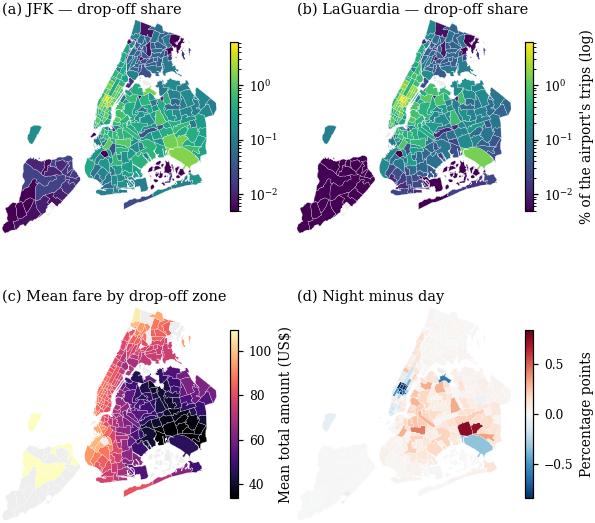

In [23]:
# --- Figure 6 --------------------------------------------------------------
share_values = pd.concat([geo["jfk_share_pct"], geo["lga_share_pct"]]).dropna()
share_norm = LogNorm(vmin=max(share_values.min(), 0.005), vmax=share_values.max())

fare_values = geo["mean_total_reported"].dropna()
fare_norm = Normalize(vmin=fare_values.quantile(0.02), vmax=fare_values.quantile(0.98))

# Clipped at the 98th percentile of magnitude so one small zone cannot
# consume the diverging scale.
spread = float(np.nanpercentile(np.abs(geo["night_minus_day_pp"]), 98))
spread = max(spread, 0.05)   # TwoSlopeNorm requires vmin < vcenter < vmax
diff_norm = TwoSlopeNorm(vmin=-spread, vcenter=0.0, vmax=spread)

PANELS = [
    ("jfk_share_pct", "(a) JFK — drop-off share",
     share_norm, SEQUENTIAL_CMAP, "% of the airport's trips (log)"),
    ("lga_share_pct", "(b) LaGuardia — drop-off share",
     share_norm, SEQUENTIAL_CMAP, "% of the airport's trips (log)"),
    ("mean_total_reported", "(c) Mean fare by drop-off zone",
     fare_norm, "magma", "Mean total amount (US$)"),
    ("night_minus_day_pp", "(d) Night minus day",
     diff_norm, DIVERGING_CMAP, "Percentage points"),
]

fig, axes = new_figure(2, 2, height=6.6)
bounds = geo.total_bounds

for index, (ax, panel) in enumerate(zip(axes.ravel(), PANELS)):
    column, title, norm, cmap, label = panel
    # Panels (a) and (b) share a scale, so only the right-hand bar is
    # labelled.
    if index == 0:
        label = ""
    geo.plot(
        column=column, ax=ax, cmap=cmap, norm=norm,
        linewidth=0.15, edgecolor="white", legend=True,
        legend_kwds={"shrink": 0.62, "label": label},
        missing_kwds={
            "color": MISSING_COLOUR, "edgecolor": "white", "linewidth": 0.15,
        },
    )
    ax.set_title(title)
    ax.set_axis_off()
    ax.set_xlim(bounds[0], bounds[2])
    ax.set_ylim(bounds[1], bounds[3])

# `tight_layout` is not used: each panel holds a fixed-aspect map, so it pads
# around the whitespace rather than removing it.
fig.subplots_adjust(wspace=0.10, hspace=0.06)
save_figure(fig, "fig06_dropoff_geography")

### Step 6a — Fare against re-hail opportunity, by drop-off zone

Three quantities are put side by side for the largest drop-off zones: what the trip pays,
how long it takes, and how readily a driver can re-hail where it ends. The last is proxied
by that zone's own citywide pickup rate, computed over all cleaned trips.

`revenue_per_engaged_hour` counts only the metered leg, so it is an upper bound for every
zone and overstates the low-hail zones most.


In [24]:
zone_table = (
    by_zone[~by_zone["dolocationid"].isin(UNKNOWN_ZONES)]
    .merge(
        zones_geo[["dolocationid", "zone_name", "borough"]],
        on="dolocationid", how="left",
    )
    .merge(
        zone_supply[["dolocationid", "pickups_per_hour"]],
        on="dolocationid", how="left",
    )
)
zone_table["revenue_per_engaged_hour"] = (
    zone_table["mean_total"] / (zone_table["mean_duration_min"] / 60.0)
)

top_zones = zone_table.nlargest(12, "trips")
print("Largest drop-off zones for airport pickups")
print(top_zones[[
    "zone_name", "borough", "share_pct", "mean_total", "mean_duration_min",
    "pickups_per_hour", "revenue_per_engaged_hour",
]].round(2).to_string(index=False))

borough_mix = (
    zone_table.groupby("borough")
    .agg(share_pct=("share_pct", "sum"), mean_total=("mean_total", "mean"))
    .sort_values("share_pct", ascending=False)
)
print("\nDrop-off borough mix")
print(borough_mix.round(2).to_string())

Largest drop-off zones for airport pickups
                zone_name   borough  share_pct  mean_total  mean_duration_min  pickups_per_hour  revenue_per_engaged_hour
Times Sq/Theatre District Manhattan       5.38       86.28              49.70            144.30                    104.16
           Midtown Center Manhattan       2.85       83.89              44.29            202.25                    113.65
            Midtown South Manhattan       2.75       84.15              40.77             99.47                    123.83
             Clinton East Manhattan       2.55       87.59              51.91            113.29                    101.25
            Midtown North Manhattan       2.29       85.41              49.06            125.76                    104.46
             Midtown East Manhattan       2.25       81.32              38.24            153.06                    127.60
              Murray Hill Manhattan       2.19       82.03              36.16            127.00        

Caption: zones with at least 500 airport drop-offs; marker area is proportional to the zone's share of airport trips; re-hail rate is the zone's own citywide pickups per hour over the study window.
Saved plots/fig07_rehail_tradeoff.png


PosixPath('/home/tavish/projects/project-1-individual-SavvyHack/plots/fig07_rehail_tradeoff.png')

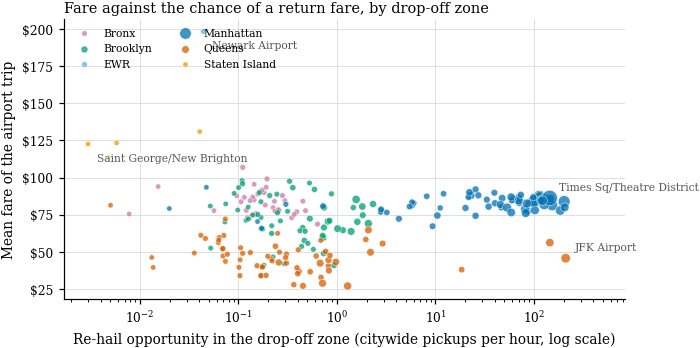

In [25]:
# --- Figure 7 --------------------------------------------------------------
BOROUGH_COLOURS = {
    "Manhattan": PALETTE["blue"],
    "Queens": PALETTE["vermillion"],
    "Brooklyn": PALETTE["green"],
    "Bronx": PALETTE["purple"],
    "Staten Island": PALETTE["orange"],
    "EWR": PALETTE["sky"],
}

plotted = zone_table[
    (zone_table["trips"] >= MIN_ZONE_TRIPS)
    & zone_table["pickups_per_hour"].notna()
].copy()

fig, ax = new_figure(height=3.4)
for borough, group in plotted.groupby("borough"):
    ax.scatter(
        group["pickups_per_hour"], group["mean_total"],
        s=12 + 90 * group["share_pct"] / plotted["share_pct"].max(),
        color=BOROUGH_COLOURS.get(borough, PALETTE["grey"]),
        alpha=0.75, edgecolors="white", linewidths=0.4, label=borough,
    )

# Four labelled zones spanning the trade-off. Labelling the five largest
# would put five adjoining Midtown labels on top of one another.
highlights = pd.concat([
    plotted.nlargest(1, "trips"),
    plotted.nlargest(1, "mean_total"),
    plotted.nsmallest(1, "pickups_per_hour"),
    plotted[plotted["borough"] == "Queens"].nlargest(1, "trips"),
]).drop_duplicates("dolocationid")

for row in highlights.itertuples():
    # Labels in the top decile of the y-axis go below their marker, clear of
    # the legend.
    high = row.mean_total > plotted["mean_total"].quantile(0.9)
    ax.annotate(
        row.zone_name, xy=(row.pickups_per_hour, row.mean_total),
        xytext=(6, -11 if high else 5), textcoords="offset points", fontsize=7,
        color=PALETTE["grey"],
        bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none",
              "alpha": 0.65},
    )

ax.set_xscale("log")
# Room on the right for the labels.
ax.set_xlim(right=float(plotted["pickups_per_hour"].max()) * 4)
ax.set_xlabel("Re-hail opportunity in the drop-off zone "
              "(citywide pickups per hour, log scale)")
ax.set_ylabel("Mean fare of the airport trip")
# Qualifiers go in the printed caption rather than in the title.
ax.set_title("Fare against the chance of a return fare, by drop-off zone")
print(f"Caption: zones with at least {MIN_ZONE_TRIPS:,} airport drop-offs; "
      "marker area is proportional to the zone's share of airport trips; "
      "re-hail rate is the zone's own citywide pickups per hour over the "
      "study window.")
currency_axis(ax)
ax.legend(loc="upper left", ncol=2, fontsize=7)

fig.tight_layout()
save_figure(fig, "fig07_rehail_tradeoff")

## Step 7 — Write the findings

The computed values notebook 4 and the report quote are written to
`data/curated/analysis_findings.json`, rather than left in an output cell, so that a figure
in the prose and the code that produced it cannot drift apart.


In [26]:
findings = {
    "distributions": {
        "cleaned_trips": int(clean_total),
        "airport_pickups": int(airport_total),
        "modal_jfk_fare": modal_fare,
        "jfk_trips_at_flat_fare": int(trips_at_flat),
        "airport_fare_upper_fence": round(airport_fare_fence, 2),
        "airport_trips_above_fare_fence": int(extreme_total),
        "airport_pct_above_fare_fence": round(
            100 * extreme_total / airport_total, 3
        ),
        "jfk_pct_at_flat_fare": round(flat_pct_jfk, 1),
        "citywide_max_fare": round(
            float(distributions.loc[
                (distributions["segment"] == "citywide")
                & (distributions["metric"] == "fare_amount"), "max"
            ].iloc[0]), 2
        ),
        "citywide_fare_variance_from_max_pct": round(
            float(distributions.loc[
                (distributions["segment"] == "citywide")
                & (distributions["metric"] == "fare_amount"),
                "max_share_of_variance",
            ].iloc[0]) * 100, 1
        ),
    },
    "target": {
        "median_dispersion_by_airport": {
            airport: round(float(value), 2)
            for airport, value in dispersion_summary["median_dispersion"].items()
        },
        "cells_overdispersed": overdispersed_cells,
        "cells_total": int(len(cells)),
        "zero_pickup_hours": int(len(zero_hours)),
        "zero_pickup_hours_genuine": int(len(genuine_zero)),
        "zero_pickup_hours_overnight_pct": round(
            100 * len(overnight) / len(zero_hours), 1
        ),
    },
    "temporal": {
        "volume_value_spearman": {
            airport: round(
                float(stats.spearmanr(
                    group.dropna(subset=["mean_pickups", "mean_total"])["mean_pickups"],
                    group.dropna(subset=["mean_pickups", "mean_total"])["mean_total"],
                ).statistic),
                3,
            )
            for airport, group in cells_long.groupby("airport")
        },
        "mean_pickups_by_day_type": {
            str(key): round(float(value), 1)
            for key, value in holiday_summary["mean_pickups_per_hour"].items()
        },
    },
    "flights": {
        "pickups_per_domestic_arrival": {
            airport: round(float(value), 2)
            for airport, value in conversion["pickups_per_arrival"].items()
        },
        "peak_correlation_lag_hours": best_lag,
    },
    "weather": {
        "observed_hours": int(len(observed)),
        "freezing_hours": int(len(freezing)),
        "freezing_matched_delta_pickups": round(float(freezing_delta), 2),
        "wettest_day": str(storm_date.date()),
        "wettest_day_vs_trailing_norm_pct": round(
            100 * (storm_pickups / storm_normal - 1), 1
        ),
        "wettest_day_vs_same_weekday_pct": round(
            100 * (storm_pickups / seasonal_norm - 1), 1
        ),
        "trailing_norm_baseline_sound": baseline_sound,
    },
    "geospatial": {
        "dropoff_zones_used": int(dropoffs["dolocationid"].nunique()),
        "unknown_zone_share_pct": round(unknown_share, 2),
        "top_dropoff_zone": str(top_zones.iloc[0]["zone_name"]),
        "top_dropoff_zone_share_pct": round(
            float(top_zones.iloc[0]["share_pct"]), 2
        ),
        "manhattan_share_pct": round(
            float(borough_mix.loc["Manhattan", "share_pct"]), 2
        ),
    },
}

with open(CURATED_DIR / "analysis_findings.json", "w") as handle:
    json.dump(findings, handle, indent=2)

print(f"Written to {CURATED_DIR / 'analysis_findings.json'}")
print("\nFigures produced:")
for path in sorted(PLOTS_DIR.glob("fig*.png")):
    print(f"  {path.name}")

Written to /home/tavish/projects/project-1-individual-SavvyHack/data/curated/analysis_findings.json

Figures produced:
  fig01_fare_distribution.png
  fig02_target_distribution.png
  fig03_hour_weekday_heatmaps.png
  fig04_flights_to_pickups.png
  fig05_weather.png
  fig06_dropoff_geography.png
  fig07_rehail_tradeoff.png


In [27]:
spark.stop()

## References

1. NYC Taxi and Limousine Commission. *Yellow Trips Data Dictionary*.
   <https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf>
2. NYC Taxi and Limousine Commission. *Taxi Zone Lookup Table and Shapefile*.
   <https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv>
3. Tukey, J. W. *Exploratory Data Analysis*. Addison-Wesley, 1977 — the 1.5 × IQR fence.
4. Okabe, M. and Ito, K. *Color Universal Design*, 2008 — the qualitative palette used by
   `scripts/plot_utils.py`.
